Importing

In [1]:
import pandas as pd

df = pd.read_csv("news_summary_more.csv",engine="python", on_bad_lines='skip')
df.head()

,headlines,text
0,upGrad learner switches to career in ML & Al w...,"Saurav Kant, an alumnus of upGrad and IIIT-B's..."
1,Delhi techie wins free food from Swiggy for on...,Kunal Shah's credit card bill payment platform...
2,New Zealand end Rohit Sharma-led India's 12-ma...,New Zealand defeated India by 8 wickets in the...
3,Aegon life iTerm insurance plan helps customer...,"With Aegon Life iTerm Insurance plan, customer..."
4,"Have known Hirani for yrs, what if MeToo claim...",Speaking about the sexual harassment allegatio...


In [2]:
df = df.rename(columns={
    "text": "article",
    "headlines": "summary"
})

In [3]:
df.info()
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98401 entries, 0 to 98400
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   summary  98401 non-null  object
 1   article  98401 non-null  object
dtypes: object(2)
memory usage: 1.5+ MB


,summary,article
0,upGrad learner switches to career in ML & Al w...,"Saurav Kant, an alumnus of upGrad and IIIT-B's..."
1,Delhi techie wins free food from Swiggy for on...,Kunal Shah's credit card bill payment platform...
2,New Zealand end Rohit Sharma-led India's 12-ma...,New Zealand defeated India by 8 wickets in the...
3,Aegon life iTerm insurance plan helps customer...,"With Aegon Life iTerm Insurance plan, customer..."
4,"Have known Hirani for yrs, what if MeToo claim...",Speaking about the sexual harassment allegatio...
...,...,...
98396,CRPF jawan axed to death by Maoists in Chhatti...,A CRPF jawan was on Tuesday axed to death with...
98397,First song from Sonakshi Sinha's 'Noor' titled...,"'Uff Yeh', the first song from the Sonakshi Si..."
98398,'The Matrix' film to get a reboot: Reports,"According to reports, a new version of the 199..."
98399,Snoop Dogg aims gun at clown dressed as Trump ...,A new music video shows rapper Snoop Dogg aimi...


Remove null & duplicates

In [4]:
df = df.dropna()
df = df.drop_duplicates()


Limit article & summary length

(Helps memory + faster training)

In [5]:
df['article_len'] = df['article'].apply(lambda x: len(x.split()))
df['summary_len'] = df['summary'].apply(lambda x: len(x.split()))

df = df[(df['article_len'] <= 300) & (df['summary_len'] <= 40)]
df

,summary,article,article_len,summary_len
0,upGrad learner switches to career in ML & Al w...,"Saurav Kant, an alumnus of upGrad and IIIT-B's...",60,13
1,Delhi techie wins free food from Swiggy for on...,Kunal Shah's credit card bill payment platform...,60,12
2,New Zealand end Rohit Sharma-led India's 12-ma...,New Zealand defeated India by 8 wickets in the...,60,9
3,Aegon life iTerm insurance plan helps customer...,"With Aegon Life iTerm Insurance plan, customer...",60,9
4,"Have known Hirani for yrs, what if MeToo claim...",Speaking about the sexual harassment allegatio...,60,13
...,...,...,...,...
98396,CRPF jawan axed to death by Maoists in Chhatti...,A CRPF jawan was on Tuesday axed to death with...,59,9
98397,First song from Sonakshi Sinha's 'Noor' titled...,"'Uff Yeh', the first song from the Sonakshi Si...",59,10
98398,'The Matrix' film to get a reboot: Reports,"According to reports, a new version of the 199...",58,8
98399,Snoop Dogg aims gun at clown dressed as Trump ...,A new music video shows rapper Snoop Dogg aimi...,58,12


Random Sampling

In [6]:
df = df.sample(n=10000, random_state=42)


Text Cleaning

In [7]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z ]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['article'] = df['article'].apply(clean_text)
df['summary'] = df['summary'].apply(clean_text)


Add Start & End Tokens (for Seq2Seq)

In [8]:
df['summary'] = "<sos> " + df['summary'] + " <eos>"


Tokenization

In [9]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

VOCAB_SIZE = 30000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<unk>")
tokenizer.fit_on_texts(df['article'].tolist() + df['summary'].tolist())


Convert Text → Sequences

In [10]:
article_seq = tokenizer.texts_to_sequences(df['article'])
summary_seq = tokenizer.texts_to_sequences(df['summary'])


Padding(Fixed Length)

In [11]:
ARTICLE_MAX_LEN = 300
SUMMARY_MAX_LEN = 40

# Re-pad sequences
encoder_input = pad_sequences(
    article_seq,
    maxlen=ARTICLE_MAX_LEN,
    padding='post'
)

decoder_input = pad_sequences(
    summary_seq,
    maxlen=SUMMARY_MAX_LEN,
    padding='post'
)

# Shift decoder
decoder_target = decoder_input[:, 1:]
decoder_input = decoder_input[:, :-1]

Tokenized & padded view

In [13]:
i = 0
encoder_input[i][:20]
decoder_input[i][:20]

array([   8,    1,   63,  742,  344,  533, 1122,   20,  616, 1810,    9,
          0,    0,    0,    0,    0,    0,    0,    0,    0], dtype=int32)

Train–Validation Split

In [14]:
from sklearn.model_selection import train_test_split

enc_train, enc_val, dec_train, dec_val, tgt_train, tgt_val = train_test_split(
    encoder_input,
    decoder_input,
    decoder_target,
    test_size=0.1,
    random_state=42
)


Model Definition (Seq2Seq + Attention)

In [15]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, LSTM, Embedding, Dense,
    Attention, Concatenate
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


In [16]:
VOCAB_SIZE = 30000
EMB_DIM = 128
LSTM_UNITS = 100
ARTICLE_MAX_LEN = 300
SUMMARY_MAX_LEN = 40


ENCODER

In [17]:
encoder_inputs = Input(shape=(ARTICLE_MAX_LEN,))
enc_emb = Embedding(
    VOCAB_SIZE,
    EMB_DIM,
    mask_zero=False
)(encoder_inputs)

encoder_lstm = LSTM(
    LSTM_UNITS,
    return_sequences=True,
    return_state=True,
    dropout=0.35,
    recurrent_dropout=0.0
)
encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)


DECODER

In [18]:
decoder_inputs = Input(shape=(SUMMARY_MAX_LEN - 1,))
dec_emb = Embedding(
    VOCAB_SIZE,
    EMB_DIM,
    mask_zero=False
)(decoder_inputs)

decoder_lstm = LSTM(
    LSTM_UNITS,
    return_sequences=True,
    return_state=True,
    dropout=0.3,
    recurrent_dropout=0.3
)

decoder_outputs, _, _ = decoder_lstm(
    dec_emb,
    initial_state=[state_h, state_c]
)


LUONG ATTENTION

In [20]:
from tensorflow.keras.layers import Attention, Concatenate

luong_attention = Attention(name="luong_attention")
attn_output = luong_attention([decoder_outputs, encoder_outputs])

concat = Concatenate(axis=-1)([decoder_outputs, attn_output])



BAHDANAU ATTENTION

In [21]:
from tensorflow.keras.layers import Layer, Dense
import tensorflow as tf

class BahdanauAttention(Layer):
    def __init__(self, units):
        super().__init__()
        self.W1 = Dense(units)
        self.W2 = Dense(units)
        self.V = Dense(1)

    def call(self, encoder_outputs, decoder_outputs):
        # encoder_outputs: (batch, enc_len, units)
        # decoder_outputs: (batch, dec_len, units)

        enc_exp = tf.expand_dims(encoder_outputs, 1)
        dec_exp = tf.expand_dims(decoder_outputs, 2)

        score = self.V(
            tf.nn.tanh(
                self.W1(enc_exp) + self.W2(dec_exp)
            )
        )

        attention_weights = tf.nn.softmax(score, axis=2)
        context_vector = attention_weights * enc_exp
        context_vector = tf.reduce_sum(context_vector, axis=2)

        return context_vector

# Instantiate and apply Bahdanau attention
bahdanau_attention = BahdanauAttention(LSTM_UNITS)
context_vector = bahdanau_attention(encoder_outputs, decoder_outputs)

# Concatenate decoder outputs with the context vector
concat = Concatenate(axis=-1)([decoder_outputs, context_vector])

OUTPUT LAYER

In [22]:
decoder_dense = Dense(VOCAB_SIZE, activation="softmax")
decoder_outputs = decoder_dense(concat)

FINAL MODEL

In [23]:
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 39)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 300, 128)  │  3,840,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 39, 128)   │  3,840,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 300,      │     91,600 │ embedding[0][0]   │
│                     │ 100), (None,      │            │                   │
│                     │ 100), (None,      │            │                   │
│                     │ 100)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 39, 100), │     91,600 │ embedding_1[0][0… │
│                     │ (None, 100),      │            │ lstm[0][1],       │
│                     │ (None, 100)]      │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bahdanau_attention  │ (None, 39, 100)   │     20,301 │ lstm[0][0],       │
│ (BahdanauAttention) │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 39, 200)   │          0 │ lstm_1[0][0],     │
│ (Concatenate)       │                   │            │ bahdanau_attenti… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 39, 30000) │  6,030,000 │ concatenate_2[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 13,913,501 (53.08 MB)

 Trainable params: 13,913,501 (53.08 MB)

 Non-trainable params: 0 (0.00 B)

EARLY STOPPING

In [24]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)


TRAINING

In [25]:

history = model.fit(
    [enc_train, dec_train],
    tgt_train,
    validation_data=([enc_val, dec_val], tgt_val),
    batch_size=32,
    epochs=10,
    callbacks=[early_stop]
)


Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 75s 228ms/step - accuracy: 0.7431 - loss: 2.9804 - val_accuracy: 0.7692 - val_loss: 1.9838
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 65s 230ms/step - accuracy: 0.7684 - loss: 1.9334 - val_accuracy: 0.7698 - val_loss: 1.9488
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 64s 228ms/step - accuracy: 0.7691 - loss: 1.8863 - val_accuracy: 0.7707 - val_loss: 1.9284
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 82s 229ms/step - accuracy: 0.7701 - loss: 1.8455 - val_accuracy: 0.7716 - val_loss: 1.9162
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 65s 230ms/step - accuracy: 0.7709 - loss: 1.8106 - val_accuracy: 0.7719 - val_loss: 1.9105
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 65s 230ms/step - accuracy: 0.7718 - loss: 1.7803 - val_accuracy: 0.7717 - val_loss: 1.9098
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 65s 229ms/step - accuracy: 0.7725 - loss: 1.7529 - val_accuracy: 0.7718 - val_loss: 1.9092
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 64s 229ms/step - accuracy: 0.7733 - loss: 1

In [26]:
!pip install rouge-score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=9dbd05ac9c0d8113cd2916ca8ca2190a7c9a0ecc66e181acdb6b5af236547b2d
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


Rouge Evaluaton

In [27]:
import numpy as np
from rouge_score import rouge_scorer

Helper: tokens → sentence

In [28]:
def tokens_to_text(tokens):
    words = []
    for tok in tokens:
        if tok == 0:
            continue
        word = tokenizer.index_word.get(tok, "")
        if word in ["<sos>", "<eos>"]:
            continue
        words.append(word)
    return " ".join(words)


Predict summaries

In [29]:
# Predict on validation set
pred_probs = model.predict([enc_val, dec_val], batch_size=32)

# Convert probabilities to token IDs
pred_tokens = np.argmax(pred_probs, axis=-1)


32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 242ms/step


Initialize ROUGE and Compute ROUGE scores

In [30]:
r1, r2, rL = [], [], []

N = 50  # evaluate on first 50 validation samples


scorer = rouge_scorer.RougeScorer(
    ['rouge1', 'rouge2', 'rougeL'],
    use_stemmer=True
)

for i in range(N):
    # Ground truth
    ref_text = tokens_to_text(tgt_val[i])

    # Predicted summary
    pred_text = tokens_to_text(pred_tokens[i])

    if len(pred_text.split()) < 3:
        continue

    scores = scorer.score(ref_text, pred_text)

    r1.append(scores['rouge1'].fmeasure)
    r2.append(scores['rouge2'].fmeasure)
    rL.append(scores['rougeL'].fmeasure)


In [31]:
print("Avg ROUGE-1:", np.mean(r1))
print("Avg ROUGE-2:", np.mean(r2))
print("Avg ROUGE-L:", np.mean(rL))


Avg ROUGE-1: 0.1614144744144744
Avg ROUGE-2: 0.004222222222222223
Avg ROUGE-L: 0.15987601287601286


Training vs Validation loss

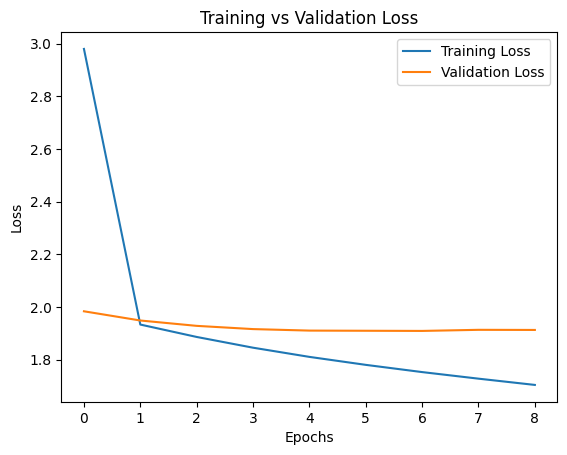

In [32]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()
